# Notebook 5: Named Entity Recognition (NER)

This notebook covers the **Named Entity Recognition** pipeline (Step 4), following Lab 2:
1. Loading the sentiment-scored dataset from Notebook 4
2. Comparing NLTK's `ne_chunk` vs spaCy NER on a sample sentence (as in Lab 2)
3. Justifying spaCy as the final method
4. Extracting entities at scale across the full dataset — `PERSON`, `ORG`, `PRODUCT`, `MONEY`, `GPE`, `DATE`
5. Canonicalising known brand entities (TikTok, Amazon, Shein, etc.) that appear in multiple casings
6. Insight extraction: top mentioned entities, entities by perspective, entities by sentiment
7. Exporting entity-level and comment-level tables for the dashboard and RAG notebooks


## Section 1 — Setup & Dependencies

In [1]:
!pip install spacy pandas matplotlib seaborn -q
!python -m spacy download en_core_web_sm -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 94.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import spacy
from tqdm import tqdm

tqdm.pandas()

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

nlp = spacy.load('en_core_web_sm')

print('All libraries loaded successfully.')


All libraries loaded successfully.


## Section 2 — Load Data

We load the sentiment-scored dataset from Notebook 4. Like Notebook 2's spaCy NER note and
Notebook 4's sentiment scoring, entity extraction runs on `light_clean_text` — casing matters
for NER since capitalisation is a strong signal for proper nouns (brand names, people, places).

In [3]:
df = pd.read_csv("sentiment_results.csv.gz")

print(f'Shape: {df.shape}')
print()
print('Columns:', list(df.columns))
df.head(3)


Shape: (51684, 17)

Columns: ['comment_id', 'video_id', 'title', 'author', 'published_at', 'like_count', 'text', 'light_clean_text', 'clean_text', 'word_count', 'char_count', 'lda_topic', 'topic', 'perspective', 'vader_sentiment', 'final_sentiment', 'final_sentiment_label']


,comment_id,video_id,title,author,published_at,like_count,text,light_clean_text,clean_text,word_count,char_count,lda_topic,topic,perspective,vader_sentiment,final_sentiment,final_sentiment_label
0,UgxmVVEhmGQ0ovq6tRR4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",@jadehannah916,2026-06-22 19:50:06+00:00,0,19:23 expiry dates have left the chat,expiry dates have left the chat,expiry date leave chat,4,22,0,-1,Outlier / Noise,0,0,Neutral
1,Ugwfz5ugRqp0yxubW9t4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",@jadehannah916,2026-06-22 19:46:57+00:00,0,16:34 just work at a grocery store at this point,just work at a grocery store at this point,work grocery store point,4,24,3,-1,Outlier / Noise,0,0,Neutral
2,UgwvTEiO61bpwRH3Dn14AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",@Sevdalina-e2l,2026-06-22 11:08:51+00:00,0,19:40 this specific content made my heart blee...,this specific content made my heart bleed. Lik...,specific content heart bleed like mean empty k...,10,61,2,6,Everyday Objects & Consumption,1,1,Positive


In [4]:
df = df.dropna(subset=['light_clean_text']).reset_index(drop=True)
df['light_clean_text'] = df['light_clean_text'].astype(str)
print(f'Rows ready for NER: {len(df):,}')


Rows ready for NER: 51,684


## Section 3 — NLTK vs spaCy NER (Lab 2 comparison)

Exactly as in Lab 2: run NLTK's `ne_chunk` and spaCy's NER on the same sample sentence
and compare.

In [5]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('maxent_ne_chunker', quiet=True)
nltk.download('maxent_ne_chunker_tab', quiet=True)
nltk.download('words', quiet=True)

sample = df['light_clean_text'].iloc[df['light_clean_text'].str.len().idxmax()]
print(sample[:300])


Globalism marches by all means and scenarios: Teil 1 : Der subjektlose Prozess der Verwertung des Werts aus Wert mehr Wert zu generieren führt vermittelt durch den stummen Zwang der Konkurrenz zum Prozess des Kapitals zum Weltkapital. Dabei bleiben schwache Nationen auf der Strecke, mittlere werden 


In [6]:
# ── NLTK NER ────────────────────────────────────────────────────────────
tokens = nltk.word_tokenize(sample)
tags = nltk.pos_tag(tokens)
tree = nltk.ne_chunk(tags)
print(tree)


(S
  (GPE Globalism/NN)
  marches/NNS
  by/IN
  all/DT
  means/NNS
  and/CC
  scenarios/NNS
  :/:
  Teil/$
  1/CD
  :/:
  (PERSON Der/NNP)
  subjektlose/VBD
  (ORGANIZATION Prozess/NNP)
  der/NN
  (ORGANIZATION Verwertung/NNP)
  des/VBZ
  (PERSON Werts/NNP)
  aus/NN
  (PERSON Wert/NNP)
  mehr/NNP
  (PERSON Wert/NNP)
  zu/NNP
  generieren/NN
  führt/NN
  vermittelt/VBD
  durch/JJ
  den/JJ
  stummen/NNS
  (PERSON Zwang/NNP)
  der/NN
  (PERSON Konkurrenz/NNP)
  zum/NNP
  Prozess/NNP
  des/FW
  (PERSON Kapitals/NNP)
  zum/NNP
  Weltkapital/NNP
  ./.
  (PERSON Dabei/NNP)
  bleiben/NN
  schwache/NN
  Nationen/NNP
  auf/NN
  der/NN
  (PERSON Strecke/NNP)
  ,/,
  mittlere/RB
  werden/JJ
  unterhöhlt/NN
  ,/,
  starke/JJ
  bilden/NN
  (PERSON Tiefe/NNP Staaten/NNP)
  aus/NN
  ./.
  (PERSON Bei/NNP)
  diesem/NN
  Prozess/NNP
  bildet/NN
  sich/JJ
  eine/JJ
  transnationale/NN
  (PERSON Ebene/NNP)
  ,/,
  bestehend/VBP
  aus/JJ
  (PERSON Multis/NNP)
  ,/,
  (GPE Multikultis/NNP)
  ,/,
  (ORGANIZA

In [7]:
# ── spaCy NER ───────────────────────────────────────────────────────────
doc = nlp(sample)
for ent in doc.ents:
    print(ent.text, "→", ent.label_)


Teil → PERSON
1 → CARDINAL
Prozess der Verwertung des Werts → ORG
Zwang der Konkurrenz zum Prozess des Kapitals → PERSON
Nationen → PERSON
der Strecke → PERSON
starke → ORG
Tiefe Staaten aus → ORG
Ebene → PERSON
aus Multis → GPE
Multikultis → NORP
EU → ORG
Globalisierung → GPE
Teil → PERSON
2 → CARDINAL
Zwang der Konkurrenz → PERSON
dem Neid → PERSON
Gier → PERSON
dem → NORP
Wunsch → ORG
Rückverfolgbarkeit → GPE
Bekämpfung von Kriminalität → PERSON
Steuerhinterziehung → GPE
dem → NORP
Wunsch → ORG
Konsument → PERSON
konsumiert → PERSON
dem → NORP
Wunsch → ORG
Kontrolle → ORG
Konsumierbarkeit → GPE
Entwicklung → PERSON
Kriege → ORG
Technologie, Information, → ORG
zusammengeschaltet gleichgeschaltet → PERSON
angeschlossen → PERSON
Maschinerie verschmilzt mit → PERSON
dem Organischen → PERSON
nationalen Staatsmaschine → PERSON
kommt → PERSON
Maschine → NORP
benötigt wird aus der Maschine → ORG
Maschine → ORG
angeschlossen → PERSON
Zentrum → PERSON
Teil → PERSON
3 → CARDINAL
Konsums → GPE


### Comparison & Final Decision

As found in Lab 2, NLTK's `ne_chunk` only distinguishes broad `PERSON`/`ORGANIZATION`/`GPE`
categories and struggles with informal, lowercase, or noisy social-media text. spaCy's NER
recognises a much richer label set out of the box — including `PRODUCT` and `MONEY`, both
essential for this project's brand/product mentions — and (as already established in
Notebook 2) spaCy's contextual model consistently outperforms NLTK's rule/statistics-based
taggers on this dataset.

**We use spaCy for NER**, extracting six entity types relevant to the de-influencing domain:
`PERSON`, `ORG`, `PRODUCT`, `MONEY`, `GPE`, `DATE`.

## Section 4 — Batch NER Extraction

Uses `nlp.pipe()` for fast batch processing, the same approach used in Notebook 2. The
`parser`, `tagger`, `lemmatizer`, and `attribute_ruler` components are disabled since NER
does not depend on them, which speeds up processing on the full dataset.

In [8]:
TARGET_LABELS = {'PERSON', 'ORG', 'PRODUCT', 'MONEY', 'GPE', 'DATE'}

def extract_entities(doc):
    return [(ent.text.strip(), ent.label_) for ent in doc.ents if ent.label_ in TARGET_LABELS]

texts = df['light_clean_text'].tolist()
docs = list(tqdm(
    nlp.pipe(texts, disable=['parser', 'tagger', 'lemmatizer', 'attribute_ruler'], batch_size=64),
    total=len(texts),
    desc='spaCy NER'
))

df['entities'] = [extract_entities(doc) for doc in docs]
df['entity_count'] = df['entities'].apply(len)

print(f'Comments with at least one target entity: {(df["entity_count"] > 0).sum():,} '
      f'({(df["entity_count"] > 0).mean()*100:.1f}%)')


spaCy NER: 100%|██████████| 51684/51684 [03:54<00:00, 220.51it/s]


Comments with at least one target entity: 21,787 (42.2%)


## Section 5 — Entity Table & Brand Canonicalisation

Explode the per-comment entity lists into a flat entity-level table, one row per mention.
Known brand names appear in multiple casings/spacings across raw comments (`tiktok`, `TikTok`,
`tik tok`), so we canonicalise the most common domain brands using the same brand list from
Notebook 2's `WHITELIST` — this keeps `entity_text` consistent for accurate frequency counts
and charts.

In [9]:
BRAND_CANONICAL = {
    'tiktok': 'TikTok', 'tik tok': 'TikTok', 'tiktoks': 'TikTok',
    'amazon': 'Amazon', 'temu': 'Temu', 'shein': 'Shein', 'nike': 'Nike',
    'apple': 'Apple', 'instagram': 'Instagram', 'youtube': 'YouTube',
    'sephora': 'Sephora', 'ulta': 'Ulta', 'zara': 'Zara', 'primark': 'Primark',
    'depop': 'Depop', 'stanley': 'Stanley',
}

def canonicalize_entity(text):
    key = text.strip().lower()
    return BRAND_CANONICAL.get(key, text.strip())

# ── Explode entities into a flat table ─────────────────────────────────────
entity_rows = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Exploding entities'):
    for ent_text, ent_label in row['entities']:
        entity_rows.append({
            'comment_id': row['comment_id'],
            'video_id': row['video_id'],
            'title': row['title'],
            'perspective': row['perspective'],
            'final_sentiment_label': row['final_sentiment_label'],
            'entity_text': canonicalize_entity(ent_text),
            'entity_label': ent_label,
        })

entities_df = pd.DataFrame(entity_rows)
print(f'Total entity mentions: {len(entities_df):,}')
entities_df.head(10)


Exploding entities: 100%|██████████| 51684/51684 [00:03<00:00, 16829.10it/s]


Total entity mentions: 42,005


,comment_id,video_id,title,perspective,final_sentiment_label,entity_text,entity_label
0,UgwvTEiO61bpwRH3Dn14AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",Everyday Objects & Consumption,Positive,😔,ORG
1,UgyrdqXOaEa7C7l8WBd4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",Outlier / Noise,Positive,glass,PERSON
2,UgxfxJBF4IPRIUuSlQl4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",Outlier / Noise,Positive,SLS,ORG
3,Ugy6Ft9zdrI7sbM3uGB4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",Outlier / Noise,Negative,Blah,PERSON
4,UgzdF8j8NUfyuGYwiFh4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",Outlier / Noise,Positive,Becka Bloom,ORG
5,UgzdF8j8NUfyuGYwiFh4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",Outlier / Noise,Positive,Rebecca Ma,PERSON
6,Ugz6HEcgyxNGF_COus14AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",Other,Positive,Idk,PERSON
7,UgxHq3PXkE7itqt7SVh4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",Outlier / Noise,Positive,IG,ORG
8,UgzMCYW7rQ8HPhZNJyZ4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",Outlier / Noise,Positive,months,DATE
9,UgzMCYW7rQ8HPhZNJyZ4AaABAg,PEY8IyB653c,"THE UNHINGED CONSUMERISM OF ""RESTOCK"" INFLUENC...",Outlier / Noise,Positive,🙏,ORG


## Section 6 — Insight Extraction

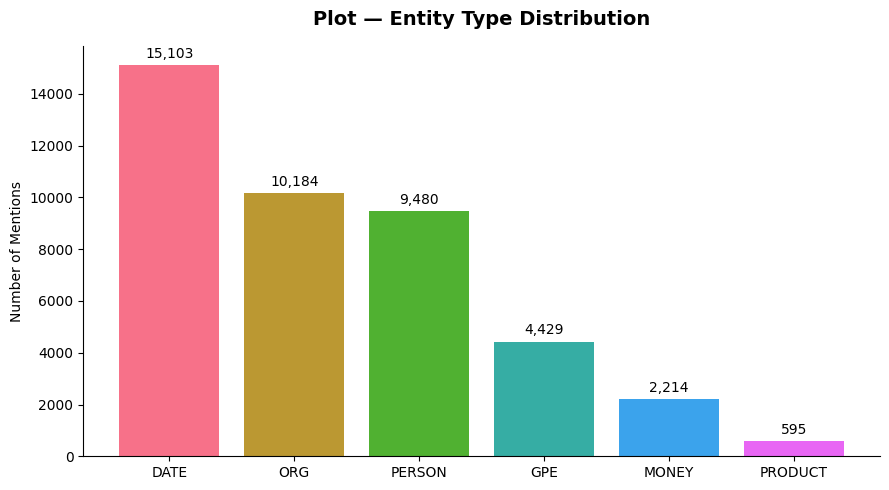

In [11]:
import os
# ── Plot 1: Entity type distribution ────────────────────────────────────
label_counts = entities_df['entity_label'].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(label_counts.index, label_counts.values, color=sns.color_palette('husl', len(label_counts)))
ax.bar_label(bars, labels=[f'{v:,}' for v in label_counts.values], padding=3)
ax.set_title('Plot — Entity Type Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of Mentions')
plt.tight_layout()
os.makedirs('eda', exist_ok=True)
plt.savefig('eda/ner_01_entity_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

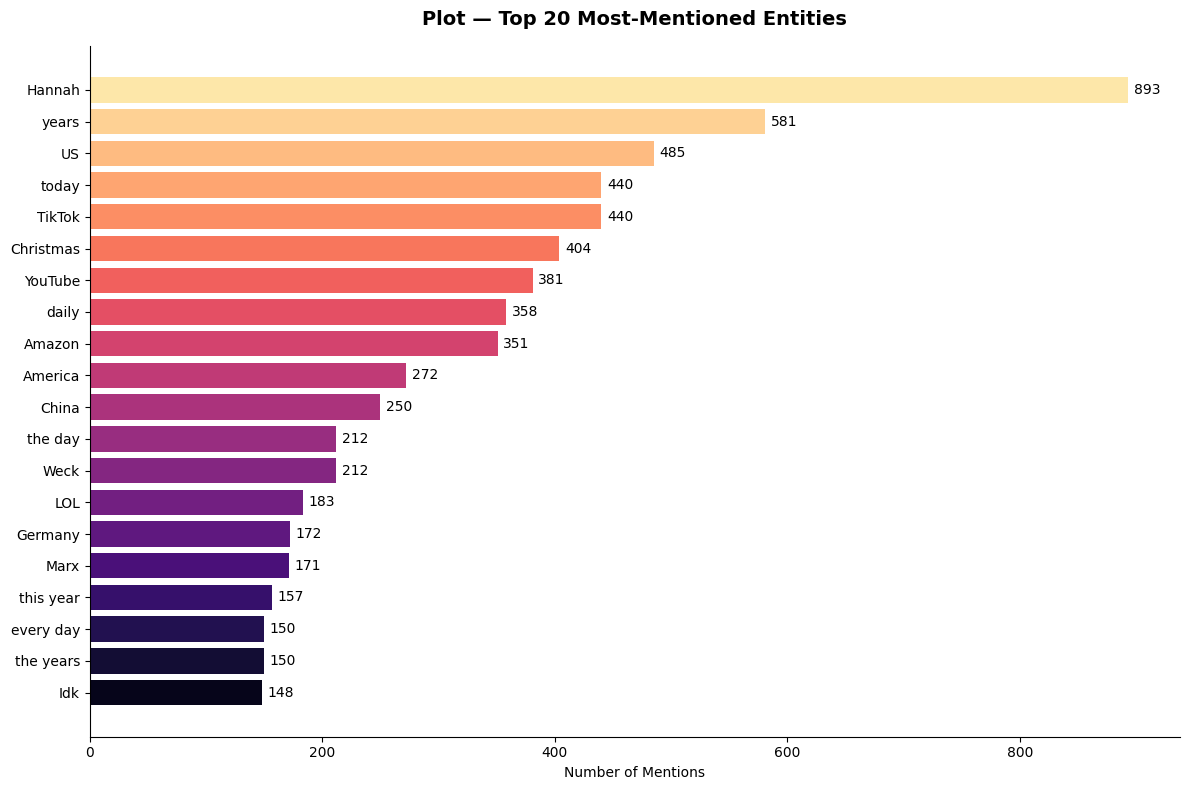

In [12]:
# ── Plot 2: Top 20 most-mentioned entities overall ─────────────────────
top_entities = entities_df['entity_text'].value_counts().head(20).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top_entities.index, top_entities.values,
               color=sns.color_palette('magma', len(top_entities)))
ax.bar_label(bars, labels=[f'{v:,}' for v in top_entities.values], padding=4)
ax.set_title('Plot — Top 20 Most-Mentioned Entities', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Mentions')
plt.tight_layout()
plt.savefig('eda/ner_02_top_entities.png', dpi=150, bbox_inches='tight')
plt.show()


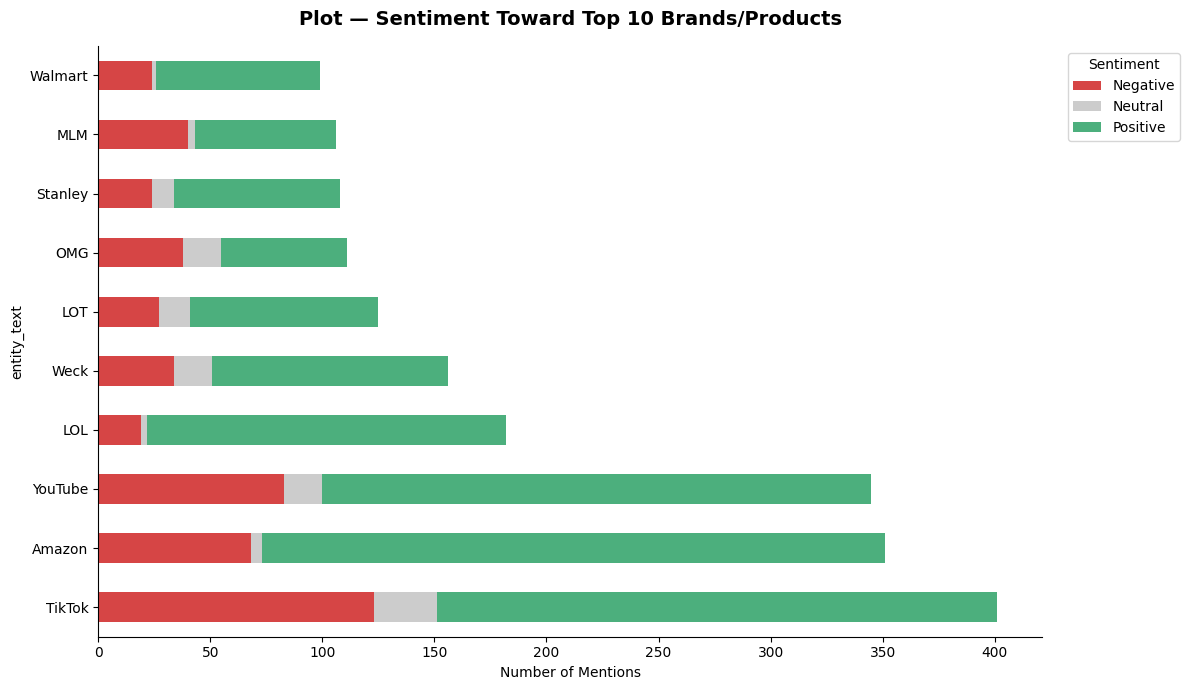

In [13]:
# ── Plot 3: Top brands/products (ORG + PRODUCT) by sentiment ───────────
brand_ents = entities_df[entities_df['entity_label'].isin(['ORG', 'PRODUCT'])]
top_brand_names = brand_ents['entity_text'].value_counts().head(10).index

brand_sentiment = pd.crosstab(
    brand_ents[brand_ents['entity_text'].isin(top_brand_names)]['entity_text'],
    brand_ents[brand_ents['entity_text'].isin(top_brand_names)]['final_sentiment_label']
)
brand_sentiment = brand_sentiment.reindex(columns=['Negative', 'Neutral', 'Positive'], fill_value=0)
brand_sentiment = brand_sentiment.loc[top_brand_names]

fig, ax = plt.subplots(figsize=(12, 7))
brand_sentiment.plot(kind='barh', stacked=True, ax=ax, color=['#d64545', '#cccccc', '#4caf7d'])
ax.set_title('Plot — Sentiment Toward Top 10 Brands/Products', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Mentions')
ax.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('eda/ner_03_brand_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# ── Plot 4: Top entities per perspective ────────────────────────────────
top_by_perspective = (
    entities_df[entities_df['entity_label'].isin(['ORG', 'PRODUCT', 'GPE'])]
    .groupby('perspective')['entity_text']
    .apply(lambda x: x.value_counts().head(5))
)
top_by_perspective


perspective                                      
Abstract / Meme / Philosophical      NEVER             4
                                     China             3
                                     UK                3
                                     US                3
                                     DIY               2
Beauty & Self-Presentation           US              100
                                     China            98
                                     America          44
                                     china            34
                                     Kiki             31
Consumerism & Material Culture       YouTube           8
                                     Blush             8
                                     ASMR              7
                                     OMG               6
                                     Social Media      5
Digital Media & Pop Culture          LOL               4
                                     YouTube           3
                                     TikTok            3
                                     glowup            2
                                     China             2
Everyday Objects & Consumption       Weck            138
                                     Germany          90
                                     Bogg             65
                                     Mason            58
                                     US               42
Health, Routine & Physical Behavior  Touchland        40
                                     touchland        13
                                     YouTube          10
                                     YouTubers         6
                                     Amazon            5
Other                                TikTok          224
                                     US               61
                                     LOL              60
                                     YouTube          57
                                     MLM              57
Outlier / Noise                      US              261
                                     YouTube         217
                                     Amazon          184
                                     America         170
                                     TikTok          147
Social Life & Identity               Amazon           50
                                     US               11
                                     Kindle           11
                                     Billie            7
                                     Google            6
Society, Economy & Power Systems     Vegan             8
                                     😡                 7
                                     7/10              5
                                     NEVER             3
                                     LOL               3
Name: entity_text, dtype: int64

In [15]:
# ── Summary table ────────────────────────────────────────────────────────
ner_summary_df = pd.DataFrame({
    'Metric': [
        'Total comments with entities',
        'Total entity mentions',
        'Unique entities (canonicalised)',
        'Most mentioned entity',
        'Most mentioned ORG/PRODUCT',
        'Entity types extracted',
    ],
    'Value': [
        f'{(df["entity_count"] > 0).sum():,}',
        f'{len(entities_df):,}',
        f'{entities_df["entity_text"].nunique():,}',
        f'{entities_df["entity_text"].value_counts().idxmax()} '
        f'({entities_df["entity_text"].value_counts().max():,} mentions)',
        f'{brand_ents["entity_text"].value_counts().idxmax()} '
        f'({brand_ents["entity_text"].value_counts().max():,} mentions)',
        ', '.join(sorted(TARGET_LABELS)),
    ]
})
display(ner_summary_df)


,Metric,Value
0,Total comments with entities,"21,787"
1,Total entity mentions,"42,005"
2,Unique entities (canonicalised),"13,486"
3,Most mentioned entity,Hannah (893 mentions)
4,Most mentioned ORG/PRODUCT,TikTok (401 mentions)
5,Entity types extracted,"DATE, GPE, MONEY, ORG, PERSON, PRODUCT"


## Section 7 — Save Results

Two outputs are exported:
- `ner_entities.csv.gz` — entity-level table (one row per mention), used for entity charts and RAG metadata filtering
- `ner_comments.csv.gz` — comment-level table with the `entities` and `entity_count` columns retained, carried forward for Notebook 6 (Keyword Extraction) and beyond

In [16]:
entities_df.to_csv('ner_entities.csv.gz', index=False, compression='gzip')

ner_comments_df = df.copy()
ner_comments_df['entities'] = ner_comments_df['entities'].apply(str)  # serialise list for CSV storage
ner_comments_df.to_csv('ner_comments.csv.gz', index=False, compression='gzip')

print(f'Saved ner_entities.csv.gz  : {len(entities_df):,} rows')
print(f'Saved ner_comments.csv.gz  : {len(ner_comments_df):,} rows')


Saved ner_entities.csv.gz  : 42,005 rows
Saved ner_comments.csv.gz  : 51,684 rows


## Summary

NLTK's `ne_chunk` and spaCy's NER were compared on the same sample text (as in Lab 2). spaCy
was chosen for the full pipeline: it recognises a richer entity set (including `PRODUCT` and
`MONEY`, both central to this project's brand-mention analysis), handles noisy social-media
casing more robustly, and is already used elsewhere in the pipeline (Notebook 2 tokenisation).

Six entity types were extracted — `PERSON`, `ORG`, `PRODUCT`, `MONEY`, `GPE`, `DATE` — and known
brand entities were canonicalised across casing variants (e.g. `tik tok` / `TikTok` / `tiktok`
→ `TikTok`) to produce clean, comparable mention counts. This directly supports the project's
business pitch: brands can now see exactly how often, and in what sentiment context, they (and
their competitors) are mentioned within anti-consumerist discourse.

**Limitation:** spaCy's `en_core_web_sm` is a general-purpose model, not fine-tuned on social
media or e-commerce text, so some brand/slang entities (e.g. platform-specific slang) may be
missed or mislabelled. This is discussed further in the report's Challenges & Limitations section.